# Interactive Lindblad Solver Gallery and Simulation Suite

This notebook compiles the complete demonstration and gallery suite for the Lindblad Master Equation Solver. We simulate and visualize all the core quantum dynamics models:
1. **$T_1$ Amplitude Damping**: Population relaxation and Bloch trajectory.
2. **$T_2$ Pure Dephasing**: Coherence decay with constant populations.
3. **Combined $T_1$ + $T_2$**: Spiraling Bloch sphere trajectories.
4. **Driven TLS (Rabi Oscillations)**: Damped oscillations to steady state under resonance and detuning.
5. **Steady State Sweeps**: Comparing SVD-based numerical steady states to analytical predictions.
6. **All Noise Channels comparison**: Bloch sphere comparison.

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.linalg import expm
from scipy.integrate import solve_ivp

# --- Core Solver Definitions (Inlined) ---
def pauli_matrices():
    sx = np.array([[0, 1], [1, 0]], dtype=complex)
    sy = np.array([[0, -1j], [1j, 0]], dtype=complex)
    sz = np.array([[1, 0], [0, -1]], dtype=complex)
    return sx, sy, sz

def spin_operators():
    sm = np.array([[0, 1], [0, 0]], dtype=complex)
    sp = np.array([[0, 0], [1, 0]], dtype=complex)
    return sm, sp

def lindblad_superoperator(H, L_list=None, gamma_list=None):
    n = H.shape[0]
    I = np.eye(n)
    L = -1j * (np.kron(I, H) - np.kron(H.T, I))
    if L_list is not None:
        if gamma_list is None:
            gamma_list = [1.0] * len(L_list)
        for Lk, gk in zip(L_list, gamma_list):
            term1 = np.kron(Lk.conj(), Lk)
            Lk_dag_Lk = Lk.conj().T @ Lk
            term2 = -0.5 * np.kron(I, Lk_dag_Lk)
            term3 = -0.5 * np.kron(Lk_dag_Lk.T, I)
            L += gk * (term1 + term2 + term3)
    return L

def lindblad_solve(H, rho0, tlist, L_list=None, gamma_list=None, method='expm'):
    n = H.shape[0]
    L_op = lindblad_superoperator(H, L_list, gamma_list)
    rho0_vec = rho0.reshape(-1, order='F')
    if method == 'expm':
        rhos = []
        for t in tlist:
            rho_t_vec = expm(L_op * t) @ rho0_vec
            rho_t = rho_t_vec.reshape(n, n, order='F')
            rhos.append(rho_t)
        return np.array(rhos)
    elif method == 'ode':
        def drho_dt(t, rho_vec):
            return L_op @ rho_vec
        sol = solve_ivp(drho_dt, [tlist[0], tlist[-1]], rho0_vec,
                        t_eval=tlist, method='DOP853', rtol=1e-12, atol=1e-14)
        return np.array([v.reshape(n, n, order='F') for v in sol.y.T])
    else:
        raise ValueError(f'Unknown method: {method}')

def steady_state(H, L_list=None, gamma_list=None):
    L_op = lindblad_superoperator(H, L_list, gamma_list)
    n = H.shape[0]
    u, s, vh = np.linalg.svd(L_op)
    rho_ss_vec = vh[-1, :].conj()
    rho_ss = rho_ss_vec.reshape(n, n, order='F')
    rho_ss = rho_ss / np.trace(rho_ss)
    return (rho_ss + rho_ss.conj().T) / 2

def bloch_vector(rho):
    sx, sy, sz = pauli_matrices()
    return np.array([
        np.trace(rho @ sx).real,
        np.trace(rho @ sy).real,
        np.trace(rho @ sz).real
    ])

# --- Noise Channels (Inlined) ---
def amplitude_damping(rho0, tlist, T1, method='expm'):
    H = np.zeros((2, 2), dtype=complex)
    sm, _ = spin_operators()
    return lindblad_solve(H, rho0, tlist, [sm], [1.0 / T1], method)

def dephasing(rho0, tlist, T2, method='expm'):
    H = np.zeros((2, 2), dtype=complex)
    _, _, sz = pauli_matrices()
    return lindblad_solve(H, rho0, tlist, [sz], [1.0 / (2 * T2)], method)

def amplitude_damping_dephasing(rho0, tlist, T1, T2, method='expm'):
    H = np.zeros((2, 2), dtype=complex)
    sm, _ = spin_operators()
    _, _, sz = pauli_matrices()
    gamma_d = 1.0 / T2 - 1.0 / (2 * T1)
    return lindblad_solve(H, rho0, tlist, [sm, sz], [1.0 / T1, gamma_d / 2], method)

# --- Driven TLS Analytical Steady State (Inlined) ---
def analytical_steady_state_driven(Omega, gamma, Delta=0.0):
    sx, sy, sz = pauli_matrices()
    denom = gamma**2 + 2 * Omega**2 + 4 * Delta**2
    x_ss = 4 * Omega * Delta / denom
    y_ss = -2 * Omega * gamma / denom
    z_ss = (gamma**2 + 4 * Delta**2) / denom
    return 0.5 * (np.eye(2) + x_ss * sx + y_ss * sy + z_ss * sz)

# --- Visualizations (Inlined) ---
def plot_bloch_sphere(ax=None, title=None):
    if ax is None:
        fig = plt.figure(figsize=(8, 8))
        ax = fig.add_subplot(111, projection='3d')
    ax.set_xlim(-1.3, 1.3)
    ax.set_ylim(-1.3, 1.3)
    ax.set_zlim(-1.3, 1.3)
    ax.set_xlabel('X')
    ax.set_ylabel('Y')
    ax.set_zlabel('Z')
    u = np.linspace(0, 2 * np.pi, 50)
    v = np.linspace(0, np.pi, 50)
    x = np.outer(np.cos(u), np.sin(v))
    y = np.outer(np.sin(u), np.sin(v))
    z = np.outer(np.ones(np.size(u)), np.cos(v))
    ax.plot_wireframe(x, y, z, color='gray', alpha=0.15, rstride=4, cstride=4)
    for axis, color, neg_label, pos_label in [
        (np.array([1, 0, 0]), 'r', '|−⟩', '|+⟩'),
        (np.array([0, 1, 0]), 'g', '|−i⟩', '|+i⟩'),
        (np.array([0, 0, 1]), 'b', '|1⟩', '|0⟩'),
    ]:
        ax.plot([-axis[0], axis[0]], [-axis[1], axis[1]], [-axis[2], axis[2]], color=color, alpha=0.6, linewidth=1)
        ax.text(-axis[0] * 1.15, -axis[1] * 1.15, -axis[2] * 1.15, neg_label, color=color, ha='center', fontsize=10)
        ax.text(axis[0] * 1.15, axis[1] * 1.15, axis[2] * 1.15, pos_label, color=color, ha='center', fontsize=10)
    ax.set_axis_off()
    if title:
        ax.set_title(title, fontsize=14)
    return ax

def plot_trajectory(bloch_vectors, ax=None, color='blue', label=None, show_initial=True, show_final=True):
    if ax is None:
        fig = plt.figure(figsize=(8, 8))
        ax = fig.add_subplot(111, projection='3d')
        plot_bloch_sphere(ax)
    bv = np.array(bloch_vectors)
    ax.plot(bv[:, 0], bv[:, 1], bv[:, 2], color=color, alpha=0.8, linewidth=2, label=label)
    if show_initial and len(bv) > 0:
        ax.scatter([bv[0, 0]], [bv[0, 1]], [bv[0, 2]], color=color, s=80, marker='o', alpha=0.7)
    if show_final and len(bv) > 0:
        ax.scatter([bv[-1, 0]], [bv[-1, 1]], [bv[-1, 2]], color=color, s=120, marker='*', alpha=1.0)
    if label:
        ax.legend(loc='upper left')
    return ax

def plot_population_vs_time(tlist, rhos, labels=None, colors=None, ax=None):
    if ax is None:
        fig, ax = plt.subplots(figsize=(10, 6))
    pops = np.array([np.diag(r).real for r in rhos])
    n = pops.shape[1]
    if labels is None:
        labels = [f'|{i}⟩' for i in range(n)]
    if colors is None:
        colors = plt.cm.viridis(np.linspace(0, 0.9, n))
    for i in range(n):
        ax.plot(tlist, pops[:, i], color=colors[i], linewidth=2, label=labels[i])
    ax.set_xlabel('Time', fontsize=12)
    ax.set_ylabel('Population', fontsize=12)
    ax.set_ylim(-0.05, 1.05)
    ax.legend(fontsize=11)
    ax.grid(True, alpha=0.3)
    return ax

def plot_coherence_vs_time(tlist, rhos, ax=None):
    if ax is None:
        fig, ax = plt.subplots(figsize=(10, 6))
    cohs = np.array([np.abs(r[0, 1]) for r in rhos])
    ax.plot(tlist, cohs, color='purple', linewidth=2, label='|ρ₀₁|')
    ax.set_xlabel('Time', fontsize=12)
    ax.set_ylabel('Coherence magnitude', fontsize=12)
    ax.set_ylim(-0.05, 1.05)
    ax.legend(fontsize=11)
    ax.grid(True, alpha=0.3)
    return ax

## 1. T₁ Amplitude Damping (Relaxation)

T₁ describes energy relaxation where an excited state $|1\rangle$ decays to $|0\rangle$ with rate $\gamma = 1/T_1$.
We plot the population decay, coherence decay, and the 3D Bloch sphere trajectory.

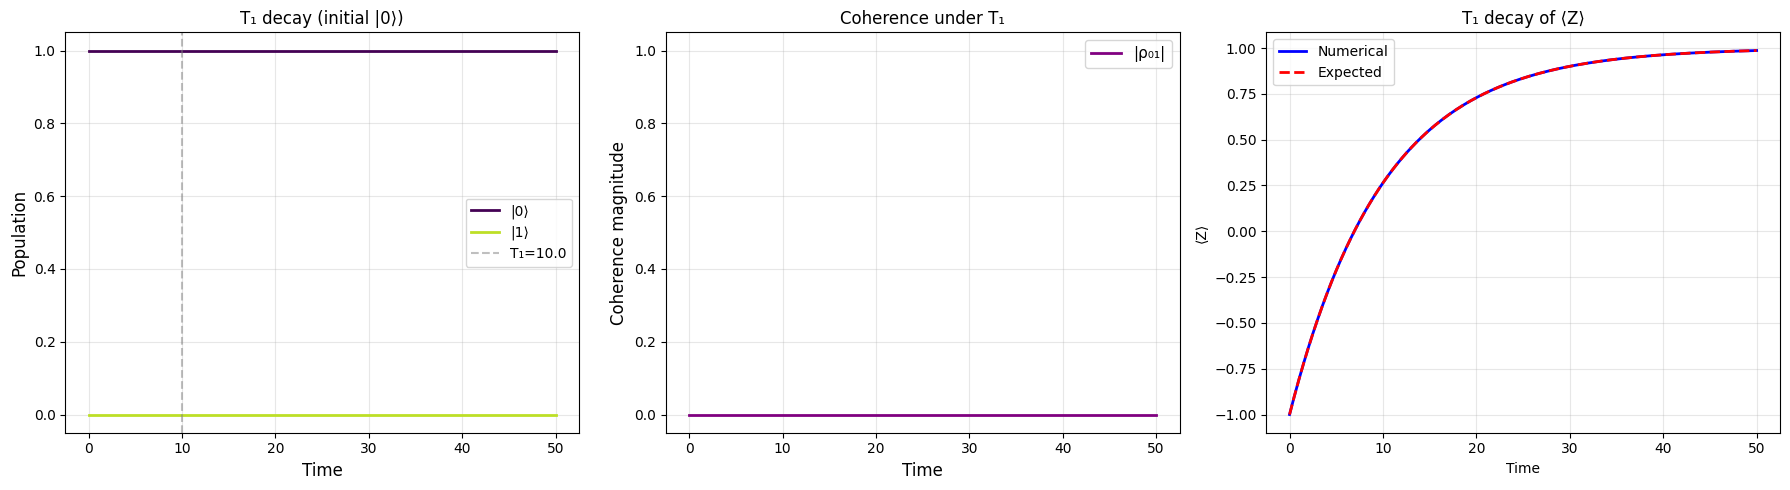

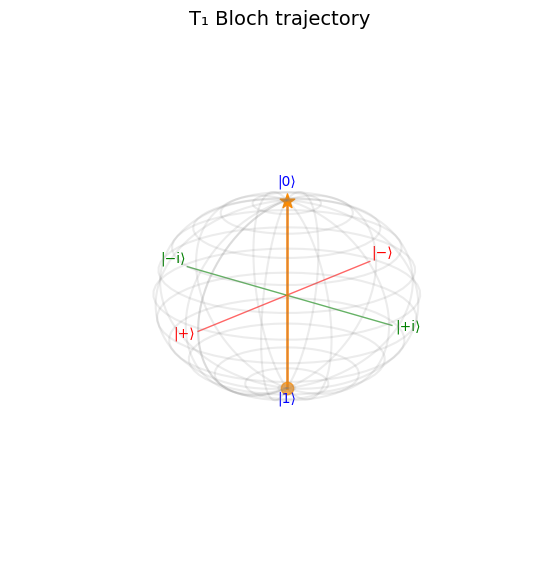

In [ ]:
T1 = 10.0
tlist = np.linspace(0, 5 * T1, 200)

rho0_ground = np.array([[1.0, 0.0], [0.0, 0.0]], dtype=complex)
rho0_excited = np.array([[0.0, 0.0], [0.0, 1.0]], dtype=complex)

rhos_ground = amplitude_damping(rho0_ground, tlist, T1)
rhos_excited = amplitude_damping(rho0_excited, tlist, T1)

# Plot populations and coherence
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
plot_population_vs_time(tlist, rhos_ground, labels=['|0⟩', '|1⟩'], ax=axes[0])
axes[0].set_title('T₁ decay (initial |0⟩)')
axes[0].axvline(x=T1, color='gray', linestyle='--', alpha=0.5, label=f'T₁={T1}')
axes[0].legend()

plot_coherence_vs_time(tlist, rhos_ground, ax=axes[1])
axes[1].set_title('Coherence under T₁')

blochs = np.array([bloch_vector(r) for r in rhos_excited])
z_expected = 1.0 - 2.0 * np.exp(-tlist / T1)
axes[2].plot(tlist, blochs[:, 2], 'b-', linewidth=2, label='Numerical')
axes[2].plot(tlist, z_expected, 'r--', linewidth=2, label='Expected')
axes[2].set_xlabel('Time')
axes[2].set_ylabel('⟨Z⟩')
axes[2].set_title('T₁ decay of ⟨Z⟩')
axes[2].legend()
axes[2].grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# 3D Bloch trajectory
fig = plt.figure(figsize=(7, 7))
ax = fig.add_subplot(111, projection='3d')
plot_bloch_sphere(ax, title='T₁ Bloch trajectory')
plot_trajectory(blochs, ax=ax, color='darkorange')
ax.view_init(elev=20, azim=40)
plt.show()

## 2. T₂ Pure Dephasing

T₂ dephasing models the loss of phase information (off-diagonal coherence) with rate $1/T_2$ while keeping populations constant.

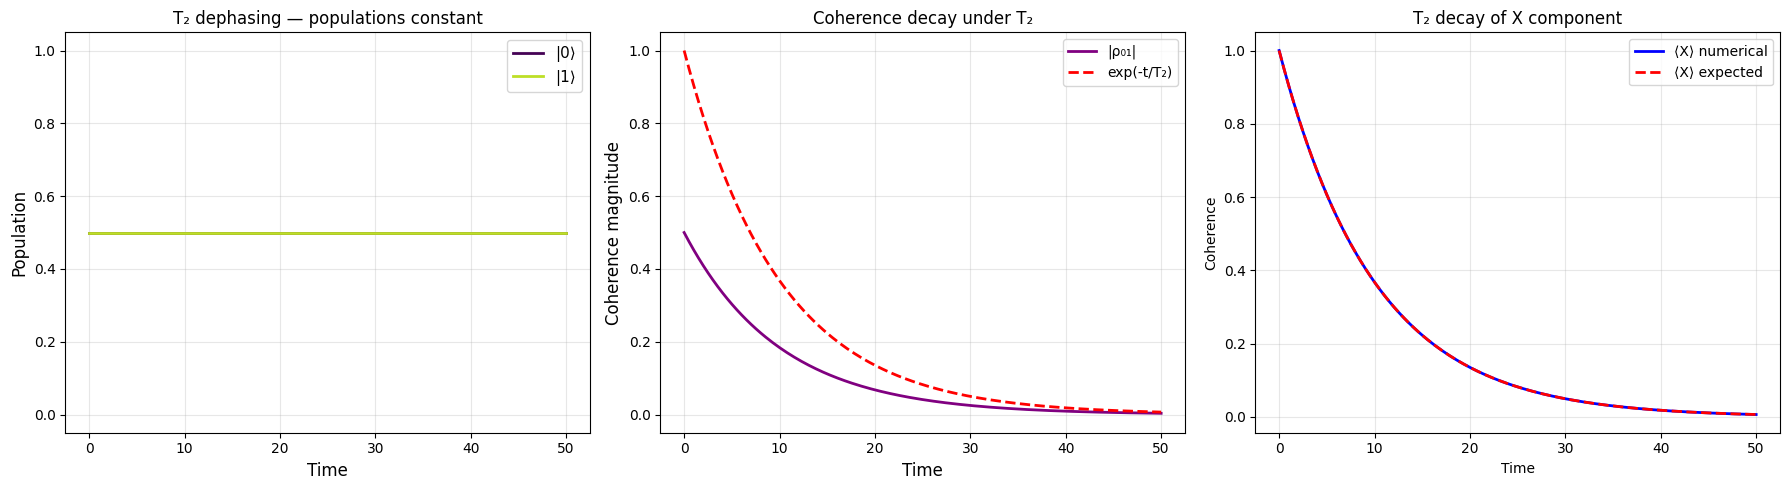

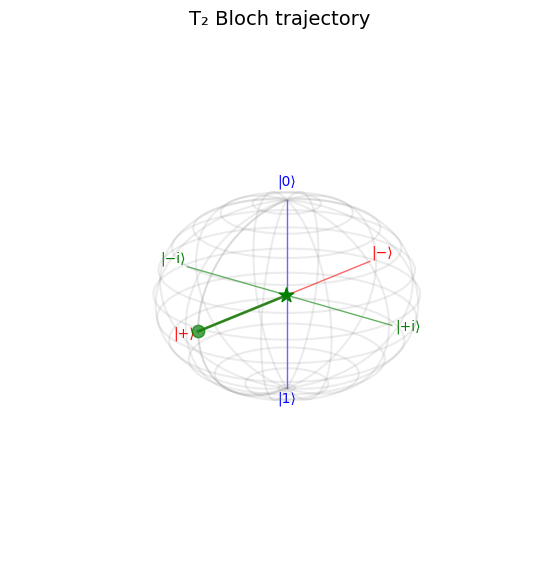

In [ ]:
T2 = 10.0
tlist = np.linspace(0, 5 * T2, 200)

rho0 = np.array([[0.5, 0.5], [0.5, 0.5]], dtype=complex)
rhos = dephasing(rho0, tlist, T2)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
plot_population_vs_time(tlist, rhos, labels=['|0⟩', '|1⟩'], ax=axes[0])
axes[0].set_title('T₂ dephasing — populations constant')

plot_coherence_vs_time(tlist, rhos, ax=axes[1])
axes[1].plot(tlist, np.exp(-tlist / T2), 'r--', linewidth=2, label='exp(-t/T₂)')
axes[1].set_title('Coherence decay under T₂')
axes[1].legend()

blochs = np.array([bloch_vector(r) for r in rhos])
axes[2].plot(tlist, blochs[:, 0], 'b-', linewidth=2, label='⟨X⟩ numerical')
axes[2].plot(tlist, np.exp(-tlist / T2), 'r--', linewidth=2, label='⟨X⟩ expected')
axes[2].set_xlabel('Time')
axes[2].set_ylabel('Coherence')
axes[2].set_title('T₂ decay of X component')
axes[2].legend()
axes[2].grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

fig = plt.figure(figsize=(7, 7))
ax = fig.add_subplot(111, projection='3d')
plot_bloch_sphere(ax, title='T₂ Bloch trajectory')
plot_trajectory(blochs, ax=ax, color='green')
ax.view_init(elev=20, azim=40)
plt.show()

## 3. Combined T₁ and T₂ Decay

Here, both relaxation and dephasing act simultaneously. The state spirals inwards towards the ground state $|0
angle$.

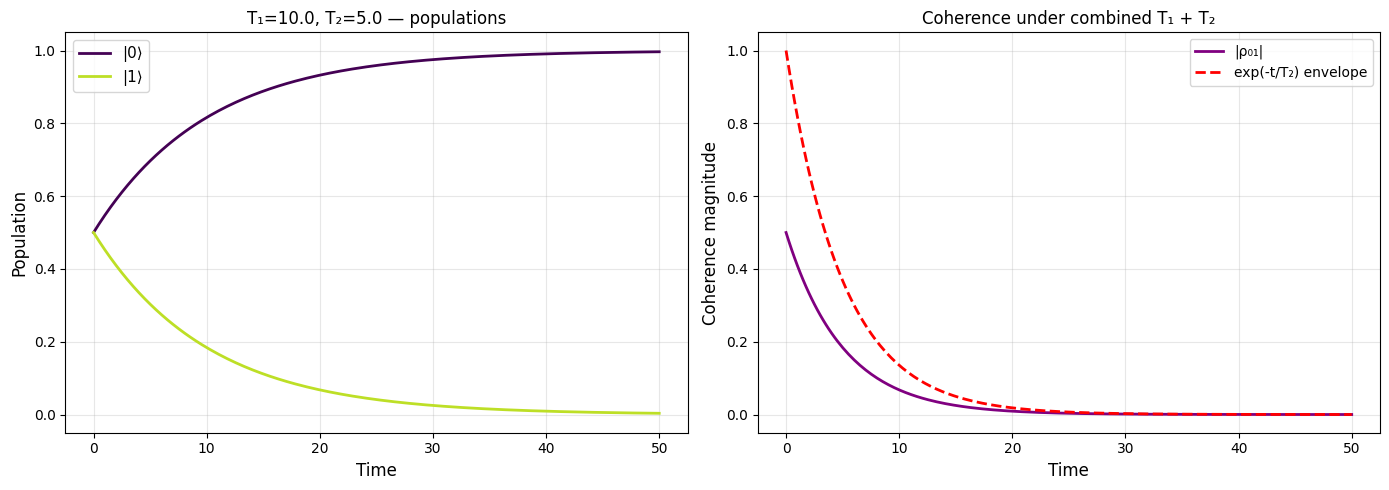

In [ ]:
T1, T2 = 10.0, 5.0
tlist = np.linspace(0, 5 * max(T1, T2), 200)

rho0 = np.array([[0.5, 0.5j], [-0.5j, 0.5]], dtype=complex)
rhos = amplitude_damping_dephasing(rho0, tlist, T1, T2)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
plot_population_vs_time(tlist, rhos, labels=['|0⟩', '|1⟩'], ax=axes[0])
axes[0].set_title(f'T₁={T1}, T₂={T2} — populations')

plot_coherence_vs_time(tlist, rhos, ax=axes[1])
axes[1].plot(tlist, np.exp(-tlist / T2), 'r--', linewidth=2, label='exp(-t/T₂) envelope')
axes[1].set_title('Coherence under combined T₁ + T₂')
axes[1].legend()
plt.tight_layout()
plt.show()

## 4. Driven Two-Level System (Damped Rabi Oscillations)

We drive the system with Rabi frequency $\Omega$ and decay rate $\gamma$. We compare the dynamics under resonance ($\Delta = 0$) and off-resonance ($\Delta = 3.0$).

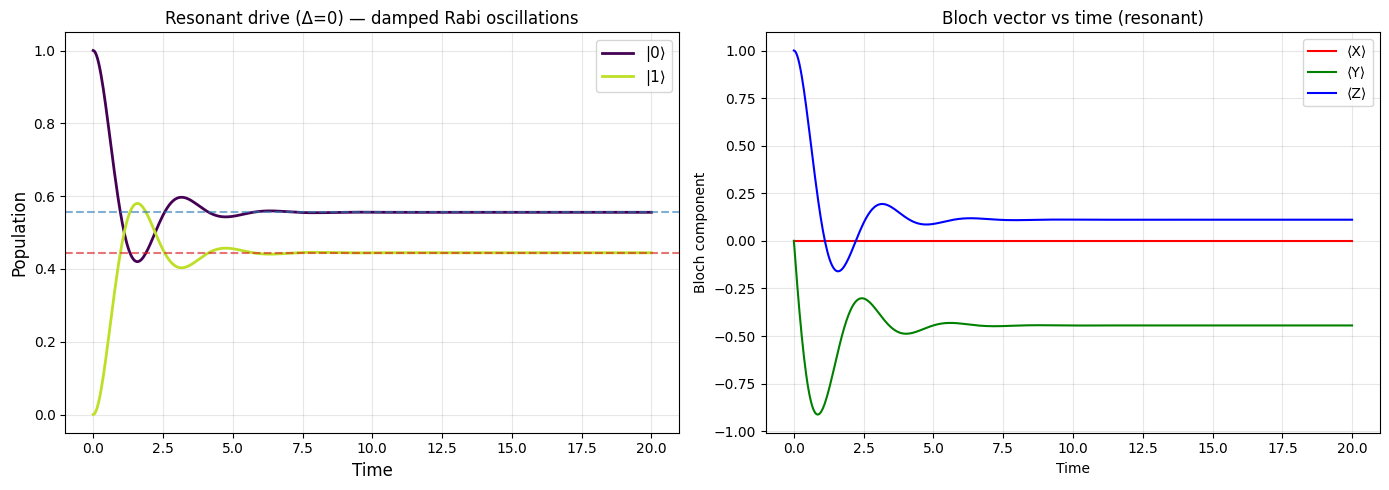

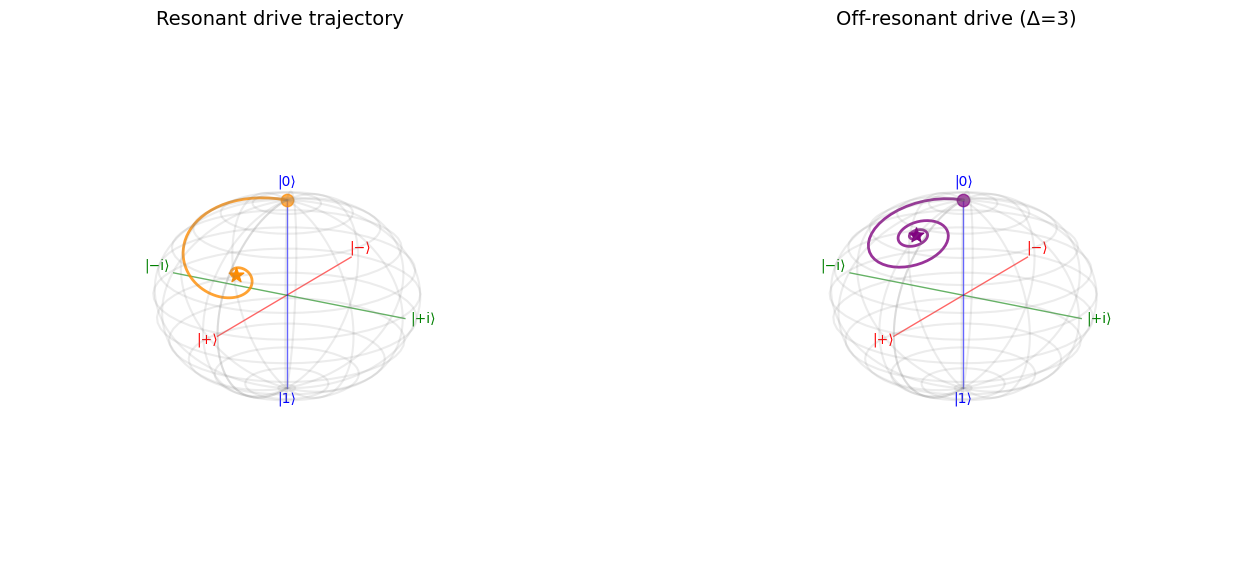

In [ ]:
Omega = 2.0
gamma = 1.0
tlist = np.linspace(0, 20, 500)
rho0 = np.array([[1.0, 0.0], [0.0, 0.0]], dtype=complex)

# Resonant Drive
sx, sy, sz = pauli_matrices()
sm, sp = spin_operators()
H_res = 0.5 * Omega * sx

L_op = -1j * (np.kron(np.eye(2), H_res) - np.kron(H_res.T, np.eye(2)))
term1 = np.kron(sm.conj(), sm)
sm_dag_sm = sm.conj().T @ sm
term2 = -0.5 * np.kron(np.eye(2), sm_dag_sm)
term3 = -0.5 * np.kron(sm_dag_sm.T, np.eye(2))
L_op += gamma * (term1 + term2 + term3)

rho0_vec = rho0.reshape(-1, order='F')
rhos_res = []
for t in tlist:
    rhos_res.append((expm(L_op * t) @ rho0_vec).reshape(2, 2, order='F'))
rhos_res = np.array(rhos_res)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
plot_population_vs_time(tlist, rhos_res, labels=['|0⟩', '|1⟩'], ax=axes[0])
axes[0].set_title('Resonant drive (Δ=0) — damped Rabi oscillations')
steady_pops = np.diag(analytical_steady_state_driven(Omega, gamma)).real
for i, c in enumerate(['#2c7bb6', '#d7191c']):
    axes[0].axhline(y=steady_pops[i], color=c, linestyle='--', alpha=0.6)

blochs = np.array([bloch_vector(r) for r in rhos_res])
axes[1].plot(tlist, blochs[:, 0], 'r-', linewidth=1.5, label='⟨X⟩')
axes[1].plot(tlist, blochs[:, 1], 'g-', linewidth=1.5, label='⟨Y⟩')
axes[1].plot(tlist, blochs[:, 2], 'b-', linewidth=1.5, label='⟨Z⟩')
axes[1].set_xlabel('Time')
axes[1].set_ylabel('Bloch component')
axes[1].set_title('Bloch vector vs time (resonant)')
axes[1].legend()
axes[1].grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# 3D Trajectories: Resonant vs Off-Resonant
fig = plt.figure(figsize=(16, 7))
ax1 = fig.add_subplot(121, projection='3d')
plot_bloch_sphere(ax1, title='Resonant drive trajectory')
plot_trajectory(blochs, ax=ax1, color='darkorange')
ax1.view_init(elev=20, azim=30)

# Off-Resonant Drive: Delta = 3.0
Delta = 3.0
H_off = 0.5 * Omega * sx + 0.5 * Delta * sz
L_op_off = -1j * (np.kron(np.eye(2), H_off) - np.kron(H_off.T, np.eye(2))) + gamma * (term1 + term2 + term3)
rhos_off = []
for t in tlist:
    rhos_off.append((expm(L_op_off * t) @ rho0_vec).reshape(2, 2, order='F'))
rhos_off = np.array(rhos_off)
blochs_off = np.array([bloch_vector(r) for r in rhos_off])

ax2 = fig.add_subplot(122, projection='3d')
plot_bloch_sphere(ax2, title='Off-resonant drive (Δ=3)')
plot_trajectory(blochs_off, ax=ax2, color='purple')
ax2.view_init(elev=20, azim=30)
plt.show()

## 5. Steady State Sweep vs Drive Strength

We sweep the Rabi drive strength $\Omega$ from $0$ to $10$ and plot the steady-state Bloch vector components, showing agreement with the analytical formula.

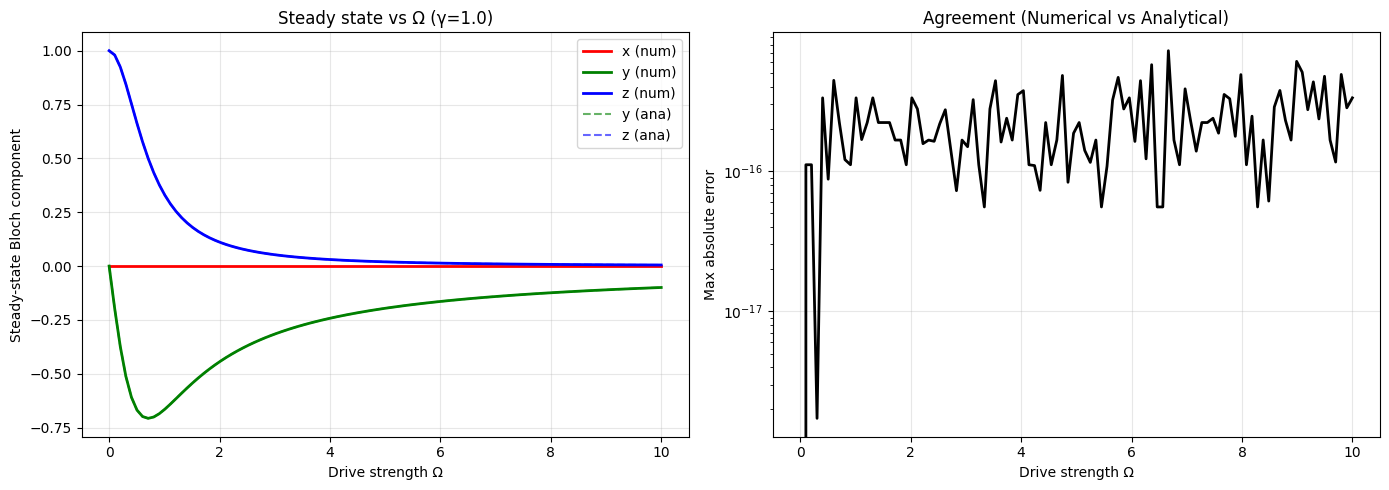

In [ ]:
Omega_range = np.linspace(0, 10, 100)
numerical = []
analytical = []

for Omg in Omega_range:
    H = 0.5 * Omg * sx
    rho_ss = steady_state(H, [sm], [gamma])
    numerical.append(bloch_vector(rho_ss))
    
    rho_ss_ana = analytical_steady_state_driven(Omg, gamma)
    analytical.append(bloch_vector(rho_ss_ana))

numerical = np.array(numerical)
analytical = np.array(analytical)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].plot(Omega_range, numerical[:, 0], 'r-', lw=2, label='x (num)')
axes[0].plot(Omega_range, numerical[:, 1], 'g-', lw=2, label='y (num)')
axes[0].plot(Omega_range, numerical[:, 2], 'b-', lw=2, label='z (num)')
axes[0].plot(Omega_range, analytical[:, 1], 'g--', lw=1.5, alpha=0.6, label='y (ana)')
axes[0].plot(Omega_range, analytical[:, 2], 'b--', lw=1.5, alpha=0.6, label='z (ana)')
axes[0].set_xlabel('Drive strength Ω')
axes[0].set_ylabel('Steady-state Bloch component')
axes[0].set_title(f'Steady state vs Ω (γ={gamma})')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

diff = np.max(np.abs(numerical - analytical), axis=1)
axes[1].semilogy(Omega_range, diff, 'k-', lw=2)
axes[1].set_xlabel('Drive strength Ω')
axes[1].set_ylabel('Max absolute error')
axes[1].set_title('Agreement (Numerical vs Analytical)')
axes[1].grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 6. Noise Channels Comparison on Bloch Sphere

Finally, we compare the trajectory of a state prepared in a superposition under three noise environments: amplitude damping, pure dephasing, and combined decay.

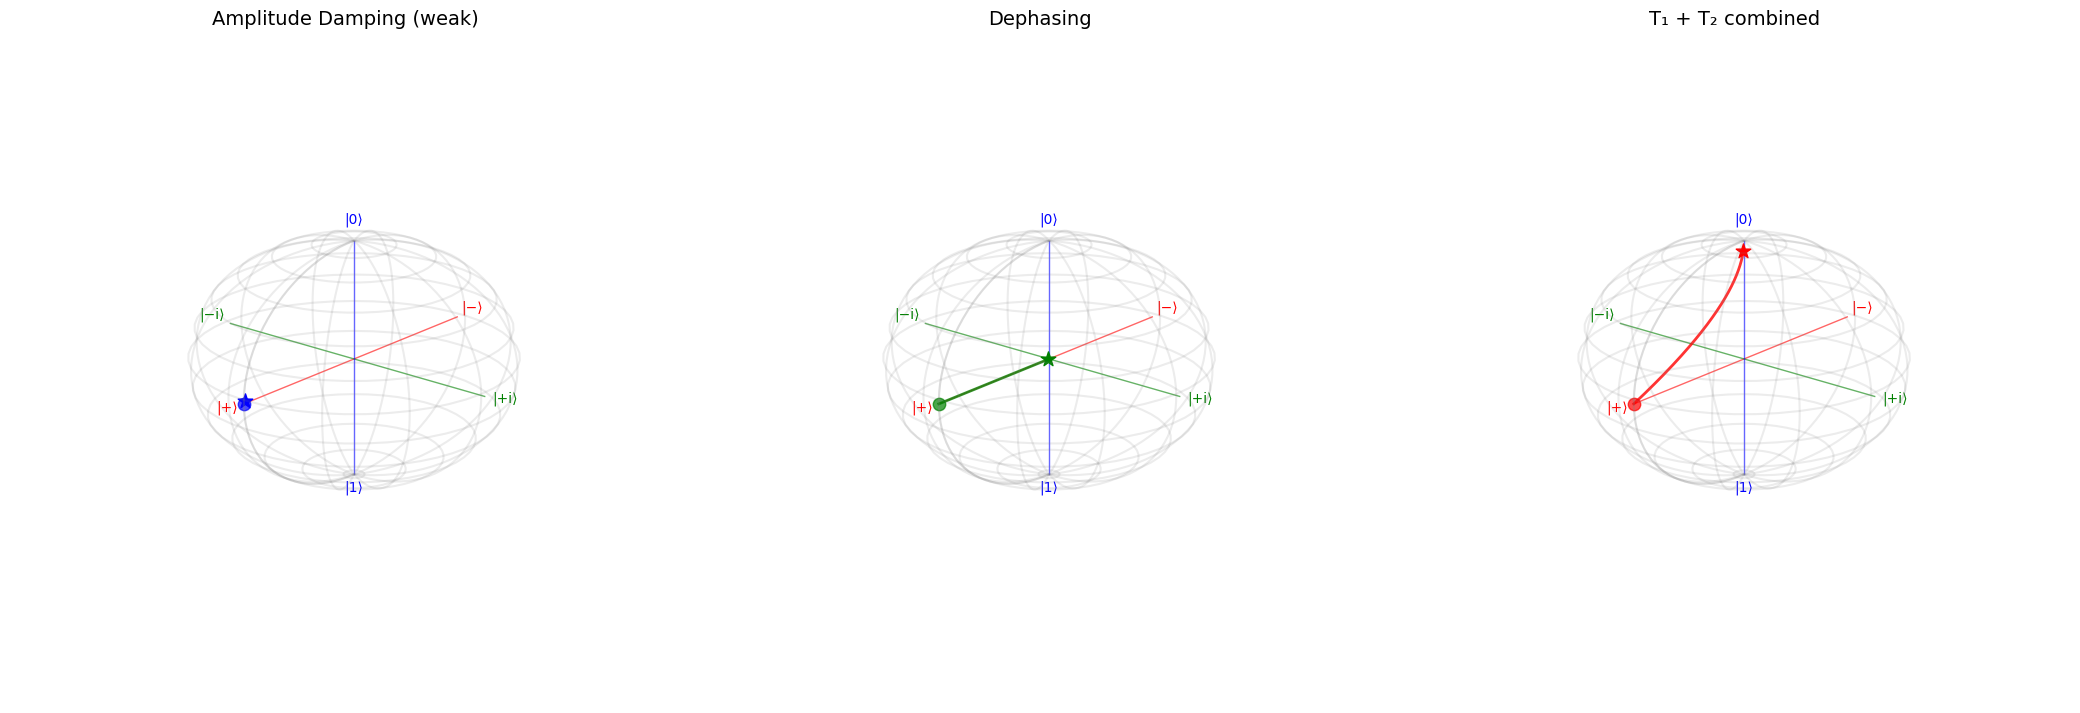

In [ ]:
T1, T2 = 8.0, 4.0
tlist = np.linspace(0, 20, 200)
rho0 = np.array([[0.5, 0.5], [0.5, 0.5]], dtype=complex) # |+><+|

rhos_ad = amplitude_damping(rho0, tlist, 1000.0) # weak AD
rhos_dp = dephasing(rho0, tlist, T2)
rhos_both = amplitude_damping_dephasing(rho0, tlist, T1, T2)

fig, axes = plt.subplots(1, 3, figsize=(21, 7), subplot_kw={'projection': '3d'})
for idx, (rhos_i, title, color) in enumerate([
    (rhos_ad, 'Amplitude Damping (weak)', 'blue'),
    (rhos_dp, 'Dephasing', 'green'),
    (rhos_both, 'T₁ + T₂ combined', 'red'),
]):
    blochs = np.array([bloch_vector(r) for r in rhos_i])
    plot_bloch_sphere(axes[idx], title=title)
    plot_trajectory(blochs, ax=axes[idx], color=color)
    axes[idx].view_init(elev=20, azim=40)
plt.tight_layout()
plt.show()